In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
data = pd.read_parquet("../data/Filtered_feature_data.parquet")

In [56]:
import pandas as pd
import numpy as np

# 假设你的数据目前存在 data 中
# ⚠️ 铁律 1：在做任何 shift 之前，必须确保数据严格按时间排序！
df_final = data.sort_values(['slug', 'timestamp']).reset_index(drop=True)

# ==========================================
# 步骤 1：绝对价格“相对化” (去除毒药，提取 Alpha)
# ==========================================
print("🔧 正在进行绝对价格相对化转换...")
if 'Up_micro_price' in df_final.columns and 'Up_Mid_Price' in df_final.columns:
    df_final['Micro_Price_Imbalance'] = df_final['Up_micro_price'] - df_final['Up_Mid_Price']

if 'bsm_theoretical_price' in df_final.columns and 'Up_Mid_Price' in df_final.columns:
    df_final['BSM_Mispricing'] = df_final['bsm_theoretical_price'] - df_final['Up_Mid_Price']

# 无情剔除绝对价格特征 (防止模型死记硬背)
cols_to_drop = ['Up_micro_price', 'bsm_theoretical_price', 'chainlink_price', 'strike_price']
df_final.drop(columns=[c for c in cols_to_drop if c in df_final.columns], inplace=True, errors='ignore')

# ==========================================
# 步骤 2：构建 Target (未来 5 秒收益率) - 必须在切尾之前！
# ==========================================
print("🎯 正在连续时间线上生成预测 Target...")
# 因为前面已经排过序了，这里直接 shift 是安全的
df_final['Target_5s_Return'] = df_final.groupby('slug')['Up_Mid_Price'].shift(-5) / df_final['Up_Mid_Price'] - 1.0

🔧 正在进行绝对价格相对化转换...
🎯 正在连续时间线上生成预测 Target...


In [57]:
df_final.columns

Index(['timestamp', 'slug', 'Net_OFI', 'macro_return_15min', 'macro_rv_15min',
       'macro_return_1h', 'macro_rv_1h', 'time_to_expiry', 'moneyness',
       'ewma_rv_1s', 'Up_price_momentum_15s', 'sigma_annualized', 'bsm_delta',
       'Up_OBI', 'Up_spread', 'Up_Mid_Price', 'Down_Mid_Price',
       'Net_Nominal_Flow', 'Net_Flow_ema_15s', 'Net_Flow_ema_60s',
       'CVD_Net_Flow', 'Whale_Imbalance_ma_10s', 'Price_Discovery_Spread',
       'Up_BUY_Urgency', 'Down_BUY_Urgency', 'BSM_Mispricing',
       'Micro_Price_Imbalance', 'Target_5s_Return'],
      dtype='object')

In [64]:
import pandas as pd
import numpy as np

def lstm_bulletproof_cleaner(df, features, global_warmup_sec=3600, local_warmup_sec=60, min_seq_length=60):
    print(f"🚀 开始执行双轴 LSTM 清洗... 初始数据量: {len(df)} 行")
    
    # 步骤 0：严格排序
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df = df.sort_values(['slug', 'timestamp']).reset_index(drop=True)

    # 步骤 1：盘中微观坑洼修复
    print("  🛠️ 正在修复盘中流动性断层 (Forward Fill)...")
    valid_features = [col for col in features if col in df.columns]
    df[valid_features] = df.groupby('slug')[valid_features].ffill()
    
    flow_keywords = ['Flow', 'Imbalance', 'Urgency', 'OFI', 'OBI']
    flow_cols = [col for col in valid_features if any(kw in col for kw in flow_keywords)]
    if flow_cols:
        df[flow_cols] = df[flow_cols].fillna(0)

    # ==========================================
    # 步骤 2A：全局系统冷启动切除 (The Macro Cut)
    # 目标：给 macro_rv_1h 这种全局特征 1 小时的系统积累时间
    # ==========================================
    print(f"  🌍 正在执行全局预热: 切除整个数据库的最前 {global_warmup_sec} 秒...")
    global_start_time = df['timestamp'].min()
    df = df[df['timestamp'] > global_start_time + pd.Timedelta(seconds=global_warmup_sec)].copy()

    # ==========================================
    # 步骤 2B：合约独立微观预热切除 (The Micro Cut)
    # 目标：给 Up_price_momentum_15s 等微观特征 60 秒的独立积累时间
    # ==========================================
    print(f"  ⏱️ 正在执行微观预热: 切除每个合约自己开盘后的头 {local_warmup_sec} 秒...")
    # 注意这里变成了计算每个合约在经过全局切除后的“独立第一行时间”
    contract_starts = df.groupby('slug')['timestamp'].transform('min')
    df = df[df['timestamp'] > contract_starts + pd.Timedelta(seconds=local_warmup_sec)].copy()

    # 步骤 3：自适应尾部死水切除
    print("  🔪 正在识别并切除尾部死水与极值市场...")
    upper_bound, lower_bound = 0.98, 0.02
    is_extreme_price = (df['Up_Mid_Price'] > upper_bound) | (df['Up_Mid_Price'] < lower_bound)
    is_late_stage = df['time_to_expiry'] < 300
    is_illiquid = df['Up_spread'] > 0.03
    
    invalid_mask = is_extreme_price | (is_late_stage & is_illiquid) | (df['time_to_expiry'] <= 0)
    df['is_valid'] = ~invalid_mask
    
    last_valid_idx_series = df[df['is_valid']].groupby('slug').apply(lambda x: x.index[-1])
    last_valid_idx_dict = last_valid_idx_series.to_dict()
    
    valid_rows = []
    for slug, group in df.groupby('slug'):
        if slug in last_valid_idx_dict:
            valid_rows.append(group.loc[:last_valid_idx_dict[slug]])
            
    if valid_rows:
        df = pd.concat(valid_rows)
    else:
        df = pd.DataFrame(columns=df.columns)

    # 步骤 4：Target NaN 与 碎片残骸清理
    print(f"  🗑️ 清理 Target 缺失与长度不足 {min_seq_length} 的碎片合约...")
    if 'Target_5s_Return' in df.columns:
        df = df.dropna(subset=['Target_5s_Return'])
        
    df = df.dropna(subset=valid_features)
    
    slug_counts = df['slug'].value_counts()
    valid_slugs = slug_counts[slug_counts >= min_seq_length].index
    df = df[df['slug'].isin(valid_slugs)].copy()
    
    df = df.drop(columns=['is_valid'], errors='ignore')
    df = df.reset_index(drop=True)
    
    print(f"✨ LSTM 终极清洗完成！当前绝对纯净数据量: {len(df)} 行\n")
    return df

In [65]:
meta_and_target = ['slug', 'timestamp', 'Target_5s_Return', 'Up_Mid_Price', 'Down_Mid_Price']

# 提取出所有的 X 特征
all_columns = df_final.columns.tolist()
all_candidate_features = [col for col in all_columns if col not in meta_and_target]

# ==========================================
# 3. 挥下屠刀，执行清洗
# ==========================================
# 你的最长 rolling feature 是 1小时(3600秒)，我们加 60 秒 buffer，传入 3660
df_clean = lstm_bulletproof_cleaner(
    df=df_final, 
    features=all_candidate_features)

🚀 开始执行双轴 LSTM 清洗... 初始数据量: 572401 行
  🛠️ 正在修复盘中流动性断层 (Forward Fill)...
  🌍 正在执行全局预热: 切除整个数据库的最前 3600 秒...
  ⏱️ 正在执行微观预热: 切除每个合约自己开盘后的头 60 秒...
  🔪 正在识别并切除尾部死水与极值市场...
  🗑️ 清理 Target 缺失与长度不足 60 的碎片合约...
✨ LSTM 终极清洗完成！当前绝对纯净数据量: 450747 行



/var/folders/j4/kwkcy_yx4s5fg992bwd59h140000gn/T/ipykernel_48789/1094237672.py:48: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  last_valid_idx_series = df[df['is_valid']].groupby('slug').apply(lambda x: x.index[-1])


In [68]:
# Tree Model Only
unique_slugs = df_clean['slug'].unique()
np.random.seed(42)
np.random.shuffle(unique_slugs)

train_size = int(len(unique_slugs) * 0.8)
train_slugs = unique_slugs[:train_size]
test_slugs = unique_slugs[train_size:]

print(f"📦 训练集: {len(train_slugs)} 个合约 | 测试集: {len(test_slugs)} 个全新合约")

train_df = df_clean[df_clean['slug'].isin(train_slugs)].copy()
test_df = df_clean[df_clean['slug'].isin(test_slugs)].copy()

# ⚠️ 核心操作：彻底打乱训练集内部的顺序，打破局部时间相关性
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

black_list = ['Target_5s_Return', 'slug', 'timestamp', 'Up_Mid_Price', 'Down_Mid_Price', 'target_logic', 'resolve_ts']
features = [col for col in train_df.columns if col not in black_list]

X_train, y_train = train_df[features], train_df['Target_5s_Return']
X_test, y_test = test_df[features], test_df['Target_5s_Return']

📦 训练集: 525 个合约 | 测试集: 132 个全新合约


In [71]:
features

['Net_OFI',
 'macro_return_15min',
 'macro_rv_15min',
 'macro_return_1h',
 'macro_rv_1h',
 'time_to_expiry',
 'moneyness',
 'ewma_rv_1s',
 'Up_price_momentum_15s',
 'sigma_annualized',
 'bsm_delta',
 'Up_OBI',
 'Up_spread',
 'Net_Nominal_Flow',
 'Net_Flow_ema_15s',
 'Net_Flow_ema_60s',
 'CVD_Net_Flow',
 'Whale_Imbalance_ma_10s',
 'Price_Discovery_Spread',
 'Up_BUY_Urgency',
 'Down_BUY_Urgency',
 'BSM_Mispricing',
 'Micro_Price_Imbalance']

In [69]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from sklearn.model_selection import GroupKFold, ParameterGrid
from scipy.stats import spearmanr
import warnings
warnings.filterwarnings('ignore')

print("🚀 开始特征重要性评估与超参数搜索...")

# ==========================================
# 1. 精简提取特征与分组标签
# ==========================================
# ⚠️ 注意：绝不使用绝对价格，只保留你的 Alpha 特征
black_list = ['Target_5s_Return', 'slug', 'timestamp', 'target_logic', 'resolve_ts', 'Up_Mid_Price', 'Down_Mid_Price']
features = [col for col in train_df.columns if col not in black_list]

# 直接提取，因为之前已经重置过 index 了，所以这三个肯定完美平行对齐
X = train_df[features]
y = train_df['Target_5s_Return']
groups = train_df['slug']

print(f"✅ 准备就绪: {len(features)} 个特征 | {len(X)} 行数据 | {groups.nunique()} 个训练集合约")

# ==========================================
# 2. 定义你想探索的超参数网格 (Hyperparameter Grid)
# ==========================================
param_grid = {
    'learning_rate': [0.01, 0.05],
    'max_depth': [3, 5, 7],               
    'num_leaves': [15, 31, 63],           
    'colsample_bytree': [0.6, 0.8],       
    'subsample': [0.8],                   
    'n_estimators': [200],                
    'objective': ['mae'],                 # 预测收益率，MAE(L1) 比 MSE(L2) 对极端异常值更鲁棒！
    'random_state': [42],
    'n_jobs': [-1]
}

grid = list(ParameterGrid(param_grid))
print(f"🔍 准备搜索 {len(grid)} 组超参数组合...\n")

# ==========================================
# 3. 开启按合约隔离的交叉验证 (GroupKFold)
# ==========================================
n_splits = 3 
gkf = GroupKFold(n_splits=n_splits)

results = []

for i, params in enumerate(grid):
    fold_maes = []
    fold_ics = []
    
    # 按照 slug 切分训练和验证，确保同一合约不会两头跑
    for train_idx, val_idx in gkf.split(X, y, groups=groups):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X.iloc[val_idx], y.iloc[val_idx]
        
        # 训练模型
        model = lgb.LGBMRegressor(**params, verbose=-1, min_gain_to_split=0.001)
        
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric='mae',
            # 使用较新的 LightGBM callback 语法
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)] 
        )
        
        # 预测验证集
        preds = model.predict(X_va)
        
        # 评估 1: MAE
        mae = np.mean(np.abs(preds - y_va))
        fold_maes.append(mae)
        
        # 评估 2: Rank IC (量化最看重的指标：预测排名能力)
        try:
            ic, _ = spearmanr(preds, y_va)
        except:
            ic = 0
        fold_ics.append(ic if not np.isnan(ic) else 0)
        
    # 记录平均表现
    avg_mae = np.mean(fold_maes)
    avg_ic = np.mean(fold_ics)
    
    results.append({
        'params': params,
        'cv_mae': avg_mae,
        'cv_ic': avg_ic
    })
    
    print(f"[{i+1:02d}/{len(grid)}] IC: {avg_ic:.4f} | MAE: {avg_mae:.6f} | depth={params['max_depth']}, lr={params['learning_rate']}, leaves={params['num_leaves']}")

# ==========================================
# 4. 选出最强王者
# ==========================================
results_df = pd.DataFrame(results)
# 量化领域，IC (正相关性) 优先级往往高于 MAE
best_model = results_df.sort_values(by='cv_ic', ascending=False).iloc[0]

print("\n🏆 ===========================================")
print("🏆 网格搜索完成！基于 Rank IC 选出的最强参数：")
print("🏆 ===========================================")
for k, v in best_model['params'].items():
    print(f"   {k}: {v}")
print(f"\n📈 最佳交叉验证 IC: {best_model['cv_ic']:.4f}")
print(f"📉 对应验证集 MAE: {best_model['cv_mae']:.6f}")

🚀 开始特征重要性评估与超参数搜索...
✅ 准备就绪: 23 个特征 | 360403 行数据 | 525 个训练集合约
🔍 准备搜索 36 组超参数组合...

[01/36] IC: 0.1769 | MAE: 0.068101 | depth=3, lr=0.01, leaves=15
[02/36] IC: 0.1769 | MAE: 0.068101 | depth=3, lr=0.01, leaves=31
[03/36] IC: 0.1769 | MAE: 0.068101 | depth=3, lr=0.01, leaves=63
[04/36] IC: 0.1812 | MAE: 0.067884 | depth=5, lr=0.01, leaves=15
[05/36] IC: 0.1880 | MAE: 0.067792 | depth=5, lr=0.01, leaves=31
[06/36] IC: 0.1877 | MAE: 0.067808 | depth=5, lr=0.01, leaves=63
[07/36] IC: 0.1820 | MAE: 0.067842 | depth=7, lr=0.01, leaves=15
[08/36] IC: 0.1893 | MAE: 0.067741 | depth=7, lr=0.01, leaves=31
[09/36] IC: 0.1949 | MAE: 0.067639 | depth=7, lr=0.01, leaves=63
[10/36] IC: 0.1887 | MAE: 0.067757 | depth=3, lr=0.05, leaves=15
[11/36] IC: 0.1887 | MAE: 0.067757 | depth=3, lr=0.05, leaves=31
[12/36] IC: 0.1887 | MAE: 0.067757 | depth=3, lr=0.05, leaves=63
[13/36] IC: 0.1953 | MAE: 0.067486 | depth=5, lr=0.05, leaves=15
[14/36] IC: 0.1961 | MAE: 0.067457 | depth=5, lr=0.05, leaves=31
[15/36]

In [75]:
best_model["params"]

{'colsample_bytree': 0.8,
 'learning_rate': 0.05,
 'max_depth': 7,
 'n_estimators': 200,
 'n_jobs': -1,
 'num_leaves': 63,
 'objective': 'mae',
 'random_state': 42,
 'subsample': 0.8}

🚀 启动 LightGBM 基线模型验证 (特征数: 23)...


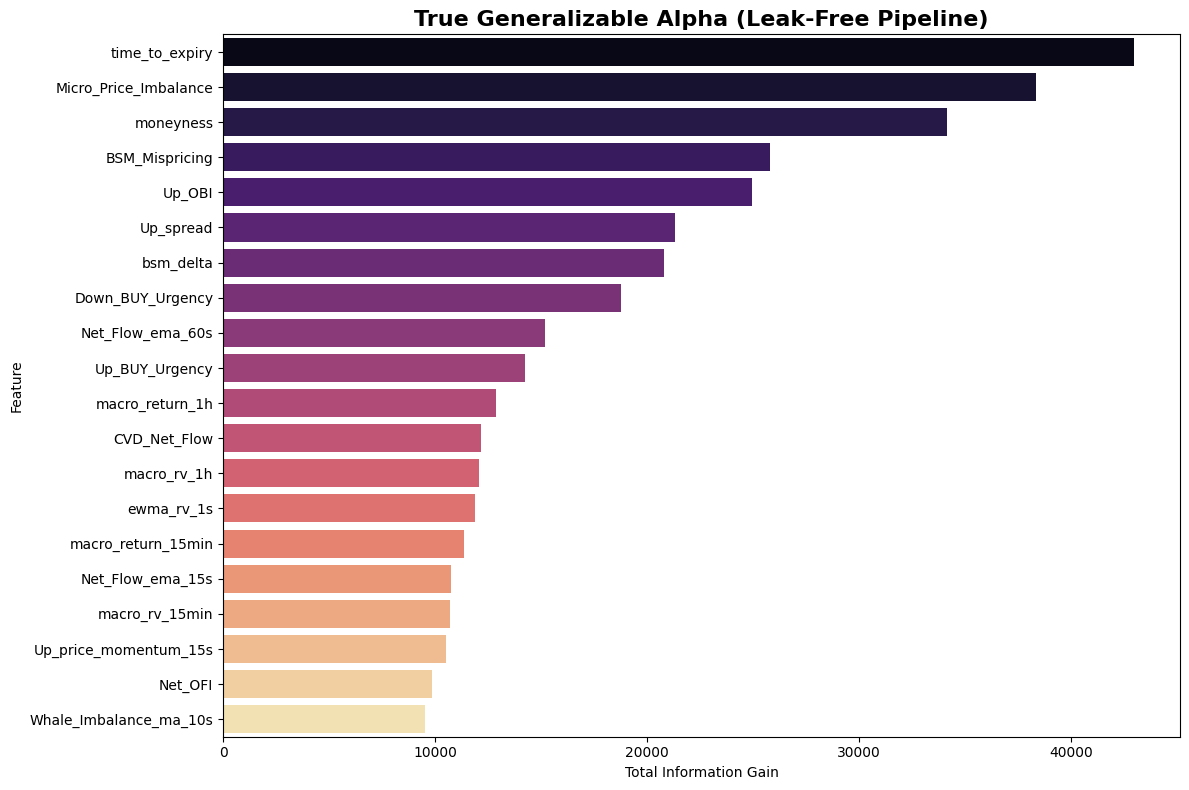

In [76]:
print(f"🚀 启动 LightGBM 基线模型验证 (特征数: {len(features)})...")

# 采用强正则化参数，逼迫模型寻找最具普适性的规律
model = lgb.LGBMRegressor(
    colsample_bytree=0.8,
    learning_rate=0.05,
    max_depth=7,
    n_estimators=200,
    n_jobs=-1,
    num_leaves=63,
    objective='mae',
    random_state=42,
    subsample=0.8,
    importance_type='gain'
)

# 训练并使用早停 (Early Stopping)
model.fit(
    X_train, y_train, 
    eval_set=[(X_test, y_test)], 
    callbacks=[lgb.early_stopping(stopping_rounds=30, verbose=False)]
)

# ==========================================
# 步骤 5：可视化真正的 Alpha 特征榜单
# ==========================================
# 💡 核心修复：直接使用模型内置的 feature_name_ 或者 X_train.columns
# 这样保证名字和重要性数值绝对是一一对应的！
importance = pd.DataFrame({
    'Feature': model.feature_name_,   # 👈 改成这里（或者写 X_train.columns）
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance.head(20), palette='magma')
plt.title('True Generalizable Alpha (Leak-Free Pipeline)', fontsize=16, fontweight='bold')
plt.xlabel('Total Information Gain')
plt.tight_layout()
plt.show()

In [97]:
import numpy as np
import pandas as pd
import lightgbm as lgb
from scipy.stats import spearmanr

# 1. 定义你的特征池和白名单 (⚠️ 修改这里：直接基于 X_train 来提取特征)
black_list = ['Target_5s_Return', 'slug', 'timestamp', 'Up_Mid_Price']
# 确保取出的特征一定在 X_train 里存在
features = [col for col in X_train.columns if col not in black_list]

# 把白名单取消注释，否则下面会报 whitelist is not defined
whitelist = ['moneyness', 'time_to_expiry'] 

# 2. 跑 3 个不同的随机种子
seeds = [42, 123, 888]
importance_list = []

print("⏳ 正在平行宇宙中疯狂建树，请稍候...")
for seed in seeds:
    model = lgb.LGBMRegressor(
    colsample_bytree=0.6,
    learning_rate=0.05,
    max_depth=7,
    n_estimators=200,
    n_jobs=-1,
    num_leaves=63,
    objective='mae',
    random_state=seed,
    subsample=0.8,
    importance_type='gain',
    verbose=-1
    )
    # 现在这里绝对不会报错了，因为 features 全是从 X_train 里拿出来的
    model.fit(X_train[features], y_train) 
    importance_list.append(model.feature_importances_)

# 3. 统计平均增益(Mean)和波动率(CV)
imp_df = pd.DataFrame(importance_list, columns=features)
stats = pd.DataFrame({
    'mean_gain': imp_df.mean(),
    'std_gain': imp_df.std()
})
# CV = 标准差 / 平均值 (CV越大，说明越不稳定)
stats['cv'] = stats['std_gain'] / stats['mean_gain']

# 4. 剔除极度不稳定的因子 (CV > 0.25)，并强行捞回白名单
stable_features = stats[stats['cv'] < 0.3].index.tolist()

for w in whitelist:
    if w not in stable_features and w in features:
        stable_features.append(w)
        print(f"🚑 触发白名单！抢救回不稳定的核心坐标: {w}")

print(f"\n✅ 步骤一完成！保留了 {len(stable_features)} 个表现稳定的特征。")

⏳ 正在平行宇宙中疯狂建树，请稍候...

✅ 步骤一完成！保留了 23 个表现稳定的特征。


In [96]:
stats

,mean_gain,std_gain,cv
Net_OFI,4985.858425,726.542533,0.145721
macro_return_15min,10139.033573,478.954021,0.047239
macro_rv_15min,12265.407883,1019.702700,0.083136
macro_return_1h,10325.349661,451.459321,0.043723
macro_rv_1h,10481.937175,311.151022,0.029684
time_to_expiry,33082.613191,1198.269511,0.036221
moneyness,29231.448647,1114.062653,0.038112
ewma_rv_1s,10619.147782,789.975606,0.074392
Up_price_momentum_15s,8653.074756,595.280916,0.068794
sigma_annualized,8999.831744,435.753196,0.048418


In [98]:
print("🔪 开始正交化清洗 (阈值: 0.85)...")

# 1. 计算留存特征的相关性矩阵
corr_matrix = X_train[stable_features].corr(method='spearman').abs()
to_drop = []

# 2. 按 Mean Gain 从高到低排序，优先保留战斗力强的
sorted_stable = stats.loc[stable_features].sort_values('mean_gain', ascending=False).index.tolist()

# 3. 👑 赋予白名单至高无上的排位（强行顶到最前面）
for w in reversed(whitelist): 
    if w in sorted_stable:
        sorted_stable.remove(w)
        sorted_stable.insert(0, w) 

# 4. 循环厮杀
for i, feat_a in enumerate(sorted_stable):
    if feat_a in to_drop: continue # 死人不能杀人
    
    for feat_b in sorted_stable[i+1:]:
        if feat_b in to_drop: continue
        
        # 如果 A 和 B 高度相关
        if corr_matrix.loc[feat_a, feat_b] > 0.85: 
            to_drop.append(feat_b) # B 被 A 杀掉 (因为 A 排名靠前/有白名单)
            
            # 播报战况
            if feat_a in whitelist:
                print(f"  🛡️ 白名单 {feat_a} 无情碾压了 {feat_b} (相关度: {corr_matrix.loc[feat_a, feat_b]:.2f})")
            else:
                print(f"  ⚔️ 强者 {feat_a} 淘汰了弱者 {feat_b} (相关度: {corr_matrix.loc[feat_a, feat_b]:.2f})")

# 5. 生成最终的 Alpha 阵容
final_features = [f for f in sorted_stable if f not in to_drop]

print(f"\n🚀 正交化完成！最终提纯出 {len(final_features)} 个正交 Alpha 特征:")
print(final_features)

🔪 开始正交化清洗 (阈值: 0.85)...
  ⚔️ 强者 Net_Flow_ema_60s 淘汰了弱者 Net_Flow_ema_15s (相关度: 0.86)
  ⚔️ 强者 ewma_rv_1s 淘汰了弱者 sigma_annualized (相关度: 1.00)

🚀 正交化完成！最终提纯出 21 个正交 Alpha 特征:
['moneyness', 'time_to_expiry', 'Micro_Price_Imbalance', 'BSM_Mispricing', 'Up_OBI', 'bsm_delta', 'Up_spread', 'Net_Flow_ema_60s', 'CVD_Net_Flow', 'Up_BUY_Urgency', 'Down_BUY_Urgency', 'macro_rv_15min', 'ewma_rv_1s', 'macro_rv_1h', 'macro_return_1h', 'macro_return_15min', 'Whale_Imbalance_ma_10s', 'Up_price_momentum_15s', 'Net_OFI', 'Price_Discovery_Spread', 'Net_Nominal_Flow']


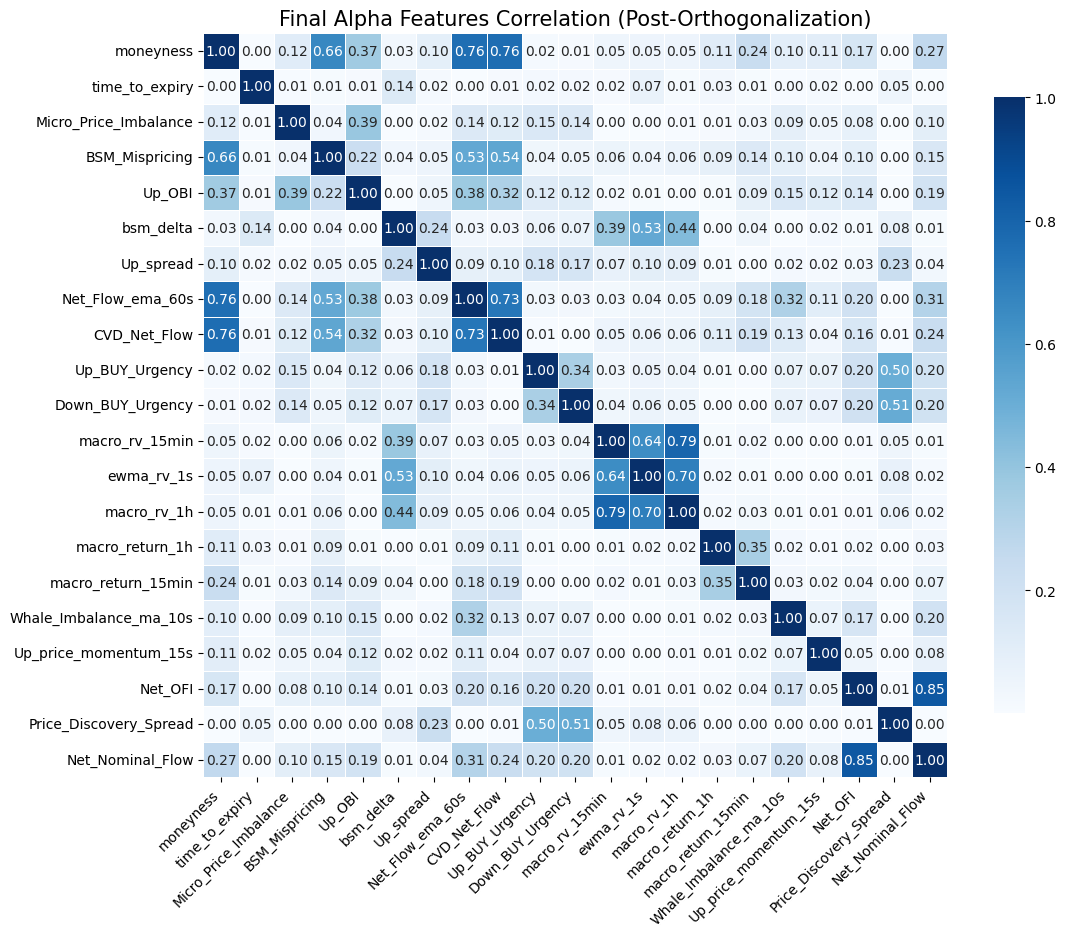

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_feature_corr(df, features, title="Feature Correlation Heatmap"):
    # 计算相关性矩阵
    corr = df[features].corr(method='spearman').abs()
    
    # 设置画布
    plt.figure(figsize=(12, 10))
    
    # 绘制热力图
    # cmap 可选 'RdBu_r', 'viridis', 'coolwarm'
    sns.heatmap(corr, annot=True, fmt=".2f", cmap='Blues', 
                cbar_kws={"shrink": .8}, square=True, linewidths=.5)
    
    plt.title(title, fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.show()

# 在你正交化结束后调用
plot_feature_corr(X_train, final_features, title="Final Alpha Features Correlation (Post-Orthogonalization)")

🕸️ 构建特征网络图 (Threshold: 0.8)...
✅ 初始特征数: 23
✅ 经过图聚类清洗后，保留 20 个正交特征:
['moneyness', 'Whale_Imbalance_ma_10s', 'time_to_expiry', 'CVD_Net_Flow', 'sigma_annualized', 'Up_OBI', 'macro_rv_15min', 'Up_spread', 'macro_rv_1h', 'bsm_delta', 'Net_Flow_ema_60s', 'Micro_Price_Imbalance', 'Net_OFI', 'Price_Discovery_Spread', 'Down_BUY_Urgency', 'macro_return_1h', 'macro_return_15min', 'Up_price_momentum_15s', 'Up_BUY_Urgency', 'BSM_Mispricing']


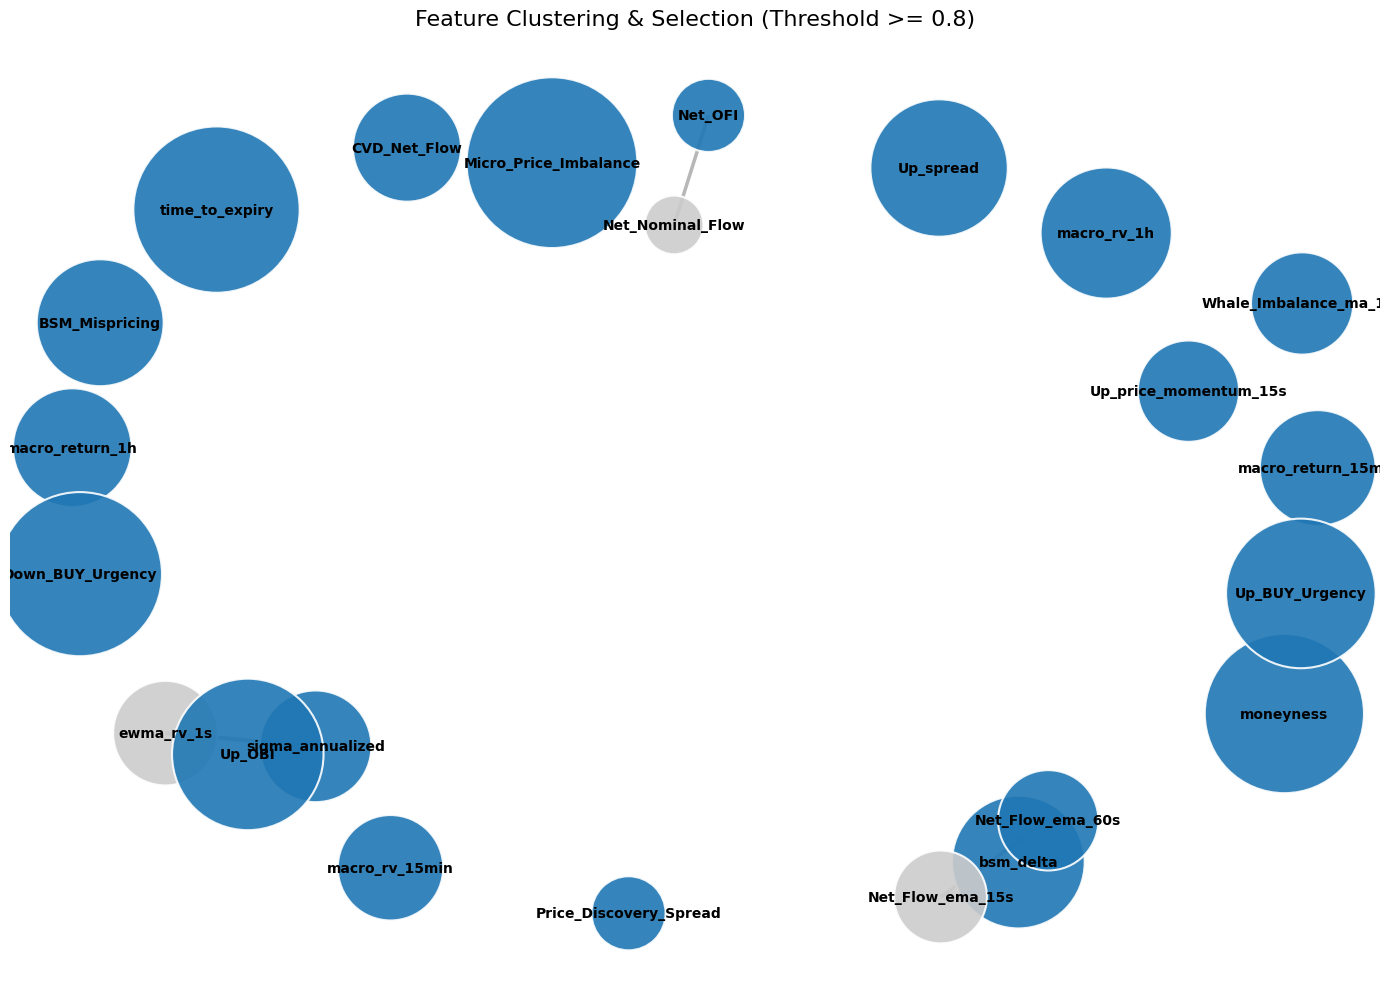

In [100]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

def plot_feature_clusters(corr_matrix, stats, threshold=0.80, whitelist=None):
    if whitelist is None:
        whitelist = ['moneyness', 'time_to_expiry']
        
    print(f"🕸️ 构建特征网络图 (Threshold: {threshold})...")
    
    # 确保 alpha_score 存在
    if 'alpha_score' not in stats.columns:
        stats['alpha_score'] = stats['mean_gain'] / (stats['cv'] + 1e-6)
        
    features = corr_matrix.columns.tolist()
    
    # 1. 初始化无向图
    G = nx.Graph()
    
    # 添加节点及其属性 (大小与 alpha_score 正相关)
    for f in features:
        # 🛡️ 增加鲁棒性：防止重复索引或 NaN 导致画图崩溃
        try:
            score = stats.loc[f, 'alpha_score']
            if isinstance(score, pd.Series): # 防止索引重复
                score = score.iloc[0]
            if pd.isna(score): # 防止出现 NaN
                score = 1000.0
        except KeyError:
            score = 1000.0
            
        G.add_node(f, score=float(score), is_whitelist=(f in whitelist))
        
    # 2. 添加边 (只添加相关性 >= threshold 的边)
    for i in range(len(features)):
        for j in range(i+1, len(features)):
            f1, f2 = features[i], features[j]
            weight = corr_matrix.iloc[i, j]
            if weight >= threshold:
                G.add_edge(f1, f2, weight=weight)
                
    # 3. 找出所有连通分量 (家族/簇) 并选拔胜出者
    components = list(nx.connected_components(G))
    winners = set()
    
    for comp in components:
        comp_list = list(comp)
        if len(comp_list) == 1:
            winners.add(comp_list[0]) # 孤勇者直接晋级
            continue
            
        # 检查白名单
        wl_in_comp = [f for f in comp_list if f in whitelist]
        if wl_in_comp:
            for w in wl_in_comp:
                winners.add(w)
        else:
            # 正常比武，选 alpha_score 最高的
            best_feat = max(comp_list, key=lambda f: G.nodes[f]['score'])
            winners.add(best_feat)
            
    # 4. 开始绘图配置
    plt.figure(figsize=(14, 10))
    # 使用 spring_layout 模拟力导向排版
    pos = nx.spring_layout(G, k=0.5, seed=42) 
    
    # 提取节点属性用于绘图 (加入 max(0, score) 防止极端负数报错)
    node_sizes = [np.sqrt(max(0, G.nodes[f]['score'])) * 15 for f in G.nodes()]
    
    # 区分晋级者(亮蓝色)和淘汰者(灰色)
    node_colors = ['#1f77b4' if f in winners else '#cccccc' for f in G.nodes()]
    
    # 🛡️ 防止没有边(阈值过高)时绘图报错
    if len(G.edges()) > 0:
        edge_colors = ['#888888' if (u in winners or v in winners) else '#eeeeee' for u, v in G.edges()]
        edge_widths = [G[u][v]['weight'] * 3 for u, v in G.edges()]
        nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=edge_widths, alpha=0.6)
        
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, 
                           edgecolors='white', linewidths=1.5, alpha=0.9)
    
    # 绘制标签 (只显示特征名字)
    labels = {f: f for f in G.nodes()}
    nx.draw_networkx_labels(G, pos, labels, font_size=10, font_weight='bold', 
                            font_family='sans-serif')
    
    # 🛡️ 图例和标题 (修复了 \ge 的转义问题)
    plt.title(f"Feature Clustering & Selection (Threshold >= {threshold})", fontsize=16)
    plt.axis('off')
    
    # 打印简报
    print(f"✅ 初始特征数: {len(features)}")
    print(f"✅ 经过图聚类清洗后，保留 {len(winners)} 个正交特征:")
    print(list(winners))
    
    plt.tight_layout()
    plt.show()

# 调用函数 (传入你之前计算好的 corr_matrix 和 stats)
plot_feature_clusters(corr_matrix, stats, threshold=0.80)

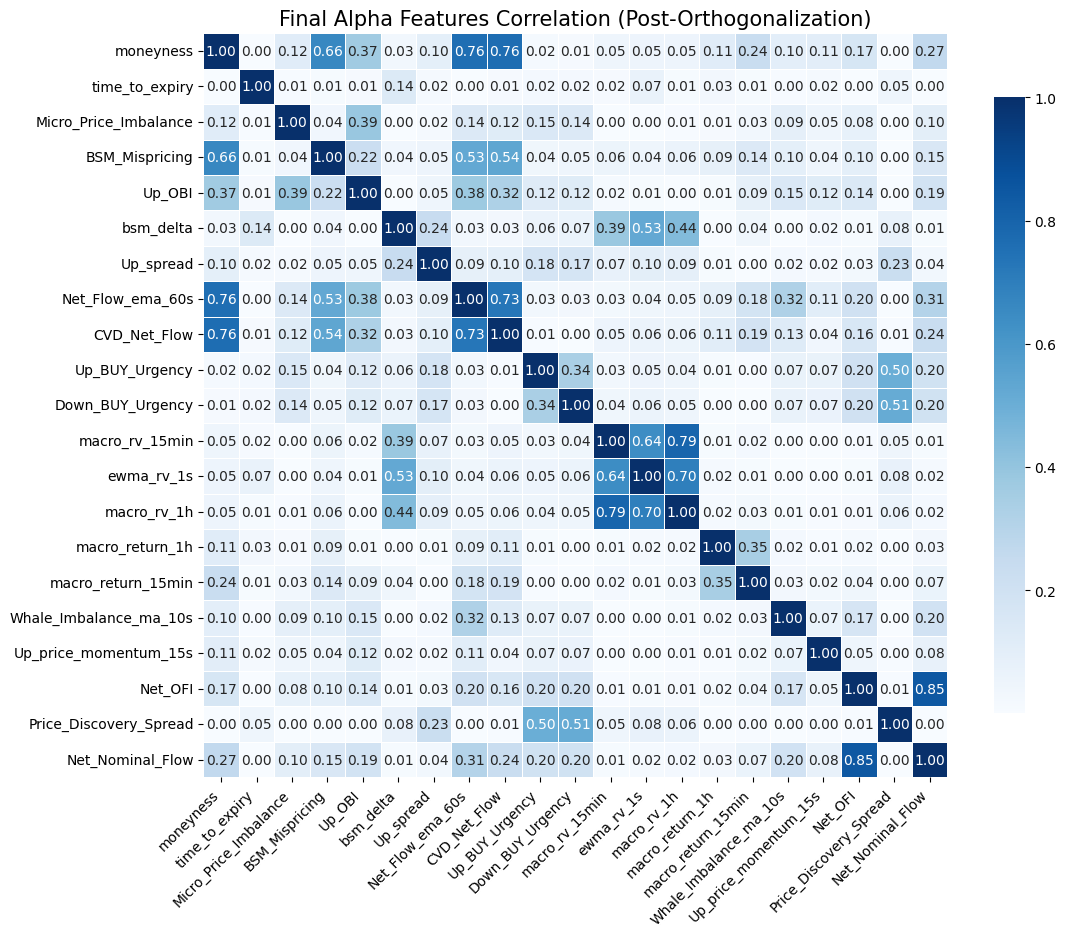

In [101]:
plot_feature_corr(X_train, final_features, title="Final Alpha Features Correlation (Post-Orthogonalization)")

In [94]:
final_features

In [102]:
from scipy.stats import spearmanr

print(f"🏆 正在使用精简后的 {len(final_features)} 个特征进行终极盲测...")

# 1. 用你之前网格搜索找出的最强参数，在全量训练集上做最后一次训练
final_model = lgb.LGBMRegressor(
    n_estimators=200, learning_rate=0.05, max_depth=7, 
    num_leaves=63, colsample_bytree=0.8, subsample=0.8,
    random_state=42, n_jobs=-1
)

final_model.fit(X_train[final_features], y_train)

# 2. 对盲测集 (test_df) 进行预测
# 注意：X_test 必须只包含 final_features 这些列
preds = final_model.predict(X_test[final_features])

# 3. 计算盲测 IC (Rank Correlation)
try:
    ic, p_value = spearmanr(preds, y_test)
except:
    ic = 0

print("\n========================================")
print(f"🌟 终极盲测 IC (Information Coefficient): {ic:.4f}")
print("========================================")

if ic > 0.03:
    print("🤑 评价：神级策略！高频 5s 预测 IC 能突破 0.03，实盘已经可以印钞了！")
elif ic > 0.01:
    print("👍 评价：有效策略！信号显著，扣除极低手续费后有盈利空间。")
else:
    print("🤔 评价：还差一点火候，模型可能在过拟合，或者测试集遇到了极端行情。")

🏆 正在使用精简后的 21 个特征进行终极盲测...

🌟 终极盲测 IC (Information Coefficient): 0.1529
🤑 评价：神级策略！高频 5s 预测 IC 能突破 0.03，实盘已经可以印钞了！


In [103]:
data_final = df_clean[final_features + ['Target_5s_Return', 'slug', 'timestamp']]
data_final.to_parquet("../data/LSTM_DATA.parquet", index=False)